In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff
import warnings
import os

warnings.filterwarnings("ignore")
os.listdir('../data')


['data_processed.csv', 'UPPLY-SEAPORTS.csv']

In [2]:
df = pd.read_csv("../data/UPPLY-SEAPORTS.csv", sep=";")
data_copia = df.copy()
df.sample(5)

,code,name,latitude,longitude,country_code,zone_code
3199,USGT9,Gardendale,32.0167,-102.3667,US,NAW-USA
9261,GBSAA,Southend-on-Sea,51.5333,0.7000,GB,EU-NEU
5369,DELGX,Ludwigshohe,49.8167,8.3500,DE,EU-NEU
4848,BETHE,Thieu,50.4670,4.0830,BE,EU-NEU
9922,HRMRG,Merag,44.9833,14.4500,HR,EU-ADR


In [3]:
df.describe()

,latitude,longitude
count,14269.000000,14269.000000
mean,39.557076,6.879715
std,23.465902,61.159516
min,-55.122510,-179.433300
25%,35.054105,-6.166700
50%,46.933300,7.583300
75%,54.643569,23.683330
max,78.933300,179.991839


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14269 entries, 0 to 14268
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   code          14269 non-null  str    
 1   name          14269 non-null  str    
 2   latitude      14269 non-null  float64
 3   longitude     14269 non-null  float64
 4   country_code  14268 non-null  str    
 5   zone_code     14269 non-null  str    
dtypes: float64(2), str(4)
memory usage: 669.0 KB


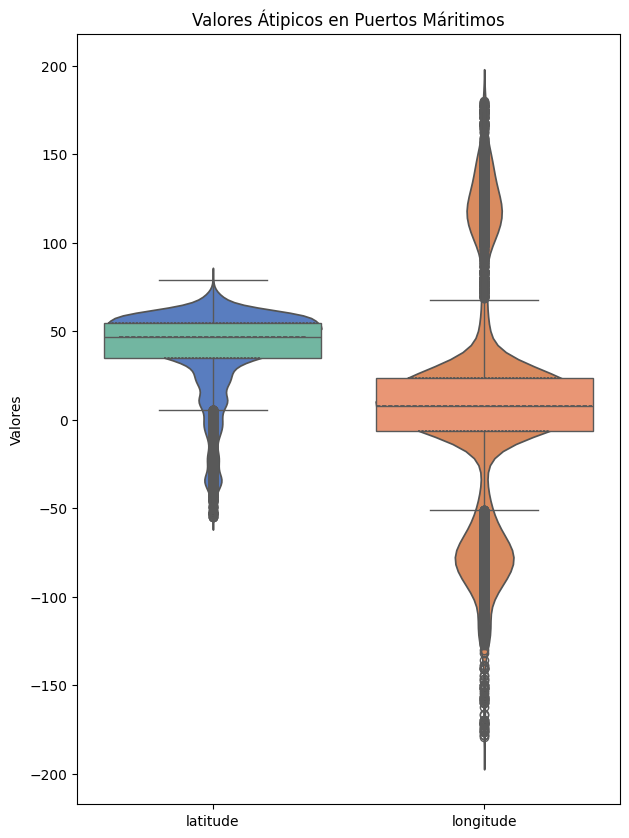

In [5]:
plt.figure(figsize = (7,10))
sns.boxplot(data=df, palette = 'Set2')
sns.violinplot(data=df, palette='muted', inner='quart')
plt.title("Valores Átipicos en Puertos Máritimos")
plt.ylabel("Valores")
plt.show()

In [7]:
df_zone = pd.DataFrame(df['zone_code'].value_counts()).reset_index()

fig = px.bar(
    df_zone,
    x = 'zone_code',
    y = 'count',  
    title="Value Counts of Zone Codes",
    color="zone_code", 
    template="plotly_white" 
)

fig.show()



In [ ]:

df_country = pd.DataFrame(df['country_code'].value_counts()).reset_index()

fig = px.bar(
    df_country,
    x = 'country_code',
    y = 'count',  
    title="Value Counts of Country Codes",
    color="country_code", 
    template="plotly_white" 
)

fig.show()



In [ ]:
fig = px.scatter_geo(
    df,
    lat = 'latitude',
    lon = 'longitude',
    color = 'country_code',
    title = 'Scatter Geo of Latitudes and Longitudes',
    template="plotly_white"   
    
)

fig.show()

In [ ]:
fig = ff.create_hexbin_map(
    df,
    lat = 'latitude',
    lon = 'longitude',
    nx_hexagon=10, 
    opacity=0.5, 
    labels={"color": "Ports Count"},
    min_count=1,
    title = 'Hexbin Map of Latitudes and Longitudes',
    template="plotly_white" 
    
)

fig.show()

In [ ]:
fig = px.line_geo(
    df,
    lat = 'latitude',
    lon = 'longitude',
    title = 'Trips Between Ports',
    template="plotly_white" 
    
)

fig.show()